# Multi-array ancestry-specific Multidimensional Scaling (maasMDS)

maasMDS is designed for multi-array genotype data. Different arrays share some SNPs, but each array also has array-specific content. If we ignore that structure, individuals tend to cluster by array. maasMDS uses pairwise SNP overlaps to calibrate distances.

## Simulate three genotyping arrays

The synthetic dataset has three arrays, each with 200 individuals and 1,000 SNPs. Each pair of arrays shares 450 SNPs, and all three arrays share 250 SNPs. The rest are array-specific.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.metrics import silhouette_score

from snputils import maasMDS
from snputils.datasets import build_synthetic_maasmds_dataset

RESULTS_DIR = Path("results/tutorials/maasmds")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20240520

dataset = build_synthetic_maasmds_dataset(
    n_samples_per_array=200,
    n_snps_per_array=1_000,
    seed=SEED,
)
snpobjs = dataset["snpobjs"]
laiobjs = dataset["laiobjs"]
labels = dataset["labels"]

print([snpobj.shape for snpobj in snpobjs])
pd.Series(dataset["overlap_counts"], name="n_snps").rename_axis("intersection").reset_index()

[(1000, 200, 2), (1000, 200, 2), (1000, 200, 2)]


,intersection,n_snps
0,array_1,1000
1,array_2,1000
2,array_3,1000
3,array_1_2,450
4,array_1_3,450
5,array_2_3,450
6,array_1_2_3,250


## A naive uncalibrated analysis clusters by array

This deliberately ignores the multi-array problem: it builds a union-SNP matrix, leaves absent array SNPs as a fixed no-call value, and runs ordinary PCA. The leading axes mostly describe which array a person came from, not their population label.

In [2]:
def array_dosage_matrix(snp):
    gt = snp.genotypes
    dosage = gt.sum(axis=2).astype(float)
    dosage[np.any(gt < 0, axis=2)] = np.nan
    return dosage.T

all_positions = sorted(set().union(*[set(snp.variants_pos.tolist()) for snp in snpobjs]))
position_index = {pos: idx for idx, pos in enumerate(all_positions)}

blocks = []
naive_labels = []
for array_id, snp in enumerate(snpobjs, start=1):
    dosage = array_dosage_matrix(snp)
    block = np.zeros((snp.n_samples, len(all_positions)), dtype=float)
    for local_idx, pos in enumerate(snp.variants_pos.tolist()):
        block[:, position_index[pos]] = np.nan_to_num(dosage[:, local_idx], nan=0.0)
    blocks.append(block)
    naive_labels.append(labels.loc[labels["array"] == array_id].copy())

X_naive = np.vstack(blocks)
naive_df = pd.concat(naive_labels, ignore_index=True)
naive_coords = SklearnPCA(n_components=2, random_state=SEED).fit_transform(X_naive)
naive_df["PC1"] = naive_coords[:, 0]
naive_df["PC2"] = naive_coords[:, 1]

naive_array_silhouette = silhouette_score(naive_coords, naive_df["array"])
naive_population_silhouette = silhouette_score(naive_coords, naive_df["label"])
print(f"Naive array silhouette: {naive_array_silhouette:.3f}")
print(f"Naive population silhouette: {naive_population_silhouette:.3f}")

Naive array silhouette: 0.964
Naive population silhouette: -0.021


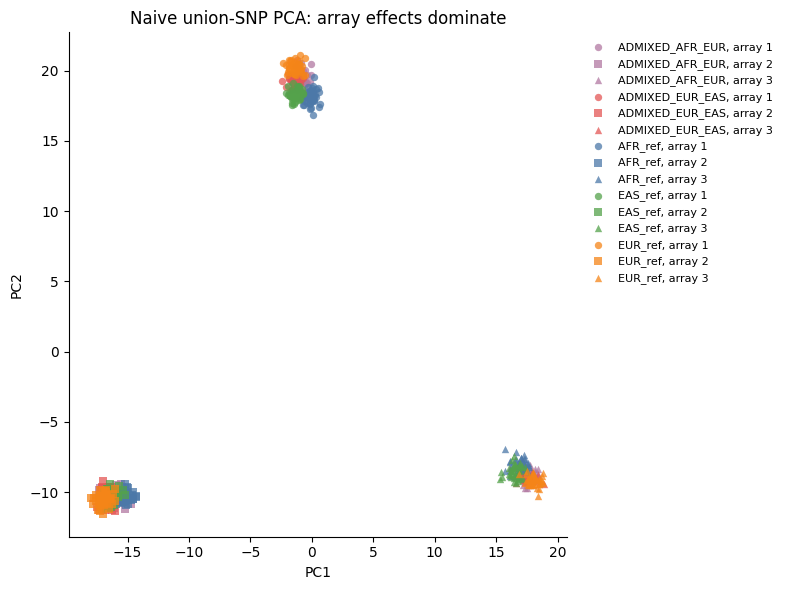

In [3]:
def plot_population_by_array(df, x="PC1", y="PC2", title=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"AFR_ref": "#4C78A8", "EUR_ref": "#F58518", "EAS_ref": "#54A24B", "ADMIXED_AFR_EUR": "#B279A2", "ADMIXED_EUR_EAS": "#E45756"}
    markers = {1: "o", 2: "s", 3: "^"}
    for (label, array_id), sub in df.groupby(["label", "array"]):
        ax.scatter(
            sub[x],
            sub[y],
            c=colors[label],
            marker=markers[int(array_id)],
            s=28,
            alpha=0.75,
            linewidths=0,
            label=f"{label}, array {array_id}",
        )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if title:
        ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)
    fig.tight_layout()
    return ax

plot_population_by_array(naive_df, title="Naive union-SNP PCA: array effects dominate")
plt.show()

## maasMDS with multi-array calibration

Passing lists of `SNPObject` and `LocalAncestryObject` instances activates the multi-array path. maasMDS computes distances within arrays and uses SNP overlaps to calibrate distances between arrays.

In [4]:
mds = maasMDS(
    snpobj=snpobjs,
    laiobj=laiobjs,
    labels=labels,
    ancestry="AFR",
    is_masked=False,
    average_strands=True,
    min_percent_snps=1,
    group_snp_frequencies_only=False,
    distance_type="AP",
    n_components=2,
)

calibrated_df = pd.DataFrame({
    "indID": mds.samples_,
    "array": mds.array_labels_,
    "MDS1": mds.X_new_[:, 0],
    "MDS2": mds.X_new_[:, 1],
}).merge(labels, on=["indID", "array"], how="left")

calibrated_array_silhouette = silhouette_score(mds.X_new_, calibrated_df["array"])
calibrated_population_silhouette = silhouette_score(mds.X_new_, calibrated_df["label"])
print(f"Calibrated array silhouette: {calibrated_array_silhouette:.3f}")
print(f"Calibrated population silhouette: {calibrated_population_silhouette:.3f}")
print("embedding shape:", mds.X_new_.shape)

Calibrated array silhouette: -0.009
Calibrated population silhouette: 0.874
embedding shape: (600, 2)


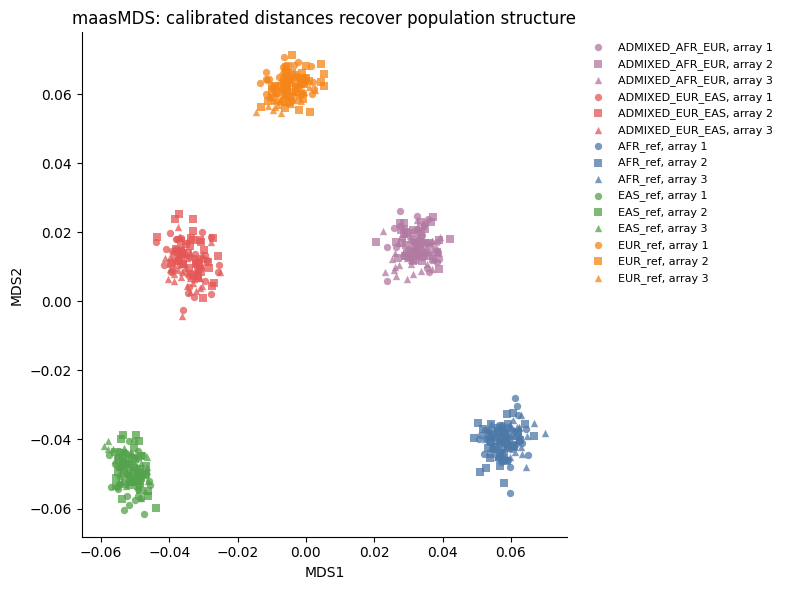

In [5]:
plot_population_by_array(
    calibrated_df,
    x="MDS1",
    y="MDS2",
    title="maasMDS: calibrated distances recover population structure",
)
plt.show()

## Compare the two analyses

The naive analysis has high array silhouette and near-zero population silhouette. After maasMDS calibration, array separation drops and population separation increases, which is the behavior the method is meant to provide for multi-array data.

In [6]:
pd.DataFrame(
    {
        "analysis": ["naive union-SNP PCA", "maasMDS calibrated"],
        "array_silhouette": [naive_array_silhouette, calibrated_array_silhouette],
        "population_silhouette": [naive_population_silhouette, calibrated_population_silhouette],
        "n_arrays": [len(snpobjs), len(snpobjs)],
        "samples_per_array": [snpobjs[0].n_samples, snpobjs[0].n_samples],
        "snps_per_array": [snpobjs[0].n_snps, snpobjs[0].n_snps],
    }
)

,analysis,array_silhouette,population_silhouette,n_arrays,samples_per_array,snps_per_array
0,naive union-SNP PCA,0.963754,-0.021381,3,200,1000
1,maasMDS calibrated,-0.008774,0.873677,3,200,1000
